In [ ]:
import subprocess
from pathlib import Path
import pyautogui
import time
import pyperclip
from pywinauto import Application
import math
import random as rd
import json
import matplotlib.pyplot as plt


rd.seed(42)

with open("AllCards.json", "r", encoding="utf-8") as f:
    card_data = json.load(f)

pyautogui.useImageNotFoundException(False)

FORGE_PATH = Path(r"C:\Users\nagvi\.cache\kagglehub\datasets\camilonunez\magic-the-gathering-top8-some-decks-and-events\versions\3\forge\forge.exe")
FORGE_DIR = FORGE_PATH.parent
DECK_DIR = Path(r"C:\Users\nagvi\AppData\Roaming\Forge\decks\constructed")
IMAGE_PATH = Path(r"C:\Users\nagvi\.cache\kagglehub\datasets\camilonunez\magic-the-gathering-top8-some-decks-and-events\versions\3\Icons")
CARD_SET_PATH = Path(r"C:\Users\nagvi\OneDrive\Documents\Iskola\Egyetem\Munkák\6. Félév\Adattudomány\card_set.txt")
LOG_PATH = Path("annealing_log.txt")
BEST_PATH = Path("best_deck.txt")

In [205]:
def write_deck(deck, name="Custom_deck"):
    path = DECK_DIR / f"{name}.dck"
    with open(path, "w", encoding="utf-8") as f:
        f.write("[metadata]\n")
        f.write(f"Name={name}\n")
        f.write("\n[Main]\n")
        for card, count in deck.items():
            f.write(f"{count} {card}\n")

def read_deck(name):
    path = DECK_DIR / f"{name}.dck"
    #print("PATH:", path)
    deck = {}
    in_main = False
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            #üres sor kihagyása
            if not line:
                continue
            #Main deck kezdete
            if line == "[Main]":
                in_main = True
                continue
            #más section
            if line.startswith("[") and line != "[Main]":
                in_main = False
                continue
            #csak a main decket olvassuk
            if in_main:
                parts = line.split(" ", 1)
                if len(parts) != 2:
                    continue
                count, card = parts
                card = card.split("|")[0].strip()
                deck[card] = int(count)
    return deck

In [206]:
def wait_for_image(name, timeout=30):
    image_path = IMAGE_PATH / name
    start = time.time()
    while time.time() - start < timeout:
        location = pyautogui.locateOnScreen(str(image_path))
        if location is not None:
            return location
        time.sleep(0.5)
    raise TimeoutError(f"{image_path} not found")

def start_forge():
    return subprocess.Popen(
        [str(FORGE_PATH)],
        cwd=str(FORGE_DIR)
    )

def focus_forge():
    app = Application(backend="win32").connect(title_re=".*Forge.*")
    window = app.top_window()
    # előtérbe hozás
    window.set_focus()
    time.sleep(1)
    return window

def close_forge():
    subprocess.run(
        ["taskkill", "/F", "/IM", "javaw.exe"],
        capture_output=True
    )
    time.sleep(2)

def restart_simulation():
    close_forge()
    time.sleep(2)
    setup_forge()

def setup_forge():
    start_forge()
    location = wait_for_image("Ajani.png", 90)
    pyautogui.click(x=743, y=206)     #"AI"
    time.sleep(0.2)
    pyautogui.click(x=269, y=6)     #"Deck editor"
    location = wait_for_image("Open_deck.png")
    pyautogui.hotkey("ctrl", "o")   #"Open deck"
    location = wait_for_image("constructed.png")
    pyautogui.click(pyautogui.center(location))  #"constructed"
    time.sleep(0.2)
    pyautogui.hotkey("enter")       #"Open"
    location = wait_for_image("enemy_deck.png")
    pyautogui.click(pyautogui.center(location))  #"Select enemy_deck"
    time.sleep(0.2)
    pyautogui.hotkey("enter")       #"Open"
    time.sleep(0.2)
    pyautogui.hotkey("ctrl", "s")   #"Save"
    time.sleep(0.2)
    pyautogui.click(x=153, y=7)     #"Home"
    location = wait_for_image("Ajani.png", 10)
    pyautogui.click(x=597, y=435)   #"Player 2 deck select"
    time.sleep(0.2)
    pyautogui.click(x=950, y=345)   #"Select enemy_deck for player"

def simulate_games(num_games):
    #Szimulál num_games db meccset, a results listbe menti a szöveges eredményeket, majd ezt interpretálja és visszaadja a winrate-et
    results_list = []
    completed = 0
    #Beállítjuk a custom_deck-et a játékosnak
    focus_forge()
    pyautogui.click(x=269, y=6)     #"Deck editor"
    location = wait_for_image("Open_deck.png")
    pyautogui.hotkey("ctrl", "o")   #"Open deck"
    location = wait_for_image("Custom_deck.png")
    pyautogui.click(pyautogui.center(location)) #"Select Custom_deck"
    time.sleep(0.2)
    pyautogui.hotkey("enter")       #"Confirm Custom_deck"
    pyautogui.hotkey("enter")
    time.sleep(0.2)
    pyautogui.hotkey("ctrl", "s")   #"Save"
    time.sleep(0.5)
    pyautogui.click(x=153, y=7)     #"Home"
    time.sleep(0.5)
    #Elindítjuk a meccsekek
    while completed < num_games:
        try:
            result = simulate_single_game()
            results_list.append(result)
            completed += 1
            #print(f"Completed: {completed}/{num_games}")
        except TimeoutError:
            print("[WARNING] Timeout")
            restart_simulation()
    final_score = interpret_result(results_list)
    return final_score        

def simulate_single_game():
    #Szimulál egyetlen meccset a jelenlegi paklival, visszaadja a szöveges eredményt
    focus_forge()
    time.sleep(0.1)
    pyautogui.click(x=667, y=667)   #"Start"
    time.sleep(2)
    pyautogui.click(x=210, y=705)   #"x10 speed"
    location = wait_for_image("Quit_match.png", 60)
    result = save_result()
    time.sleep(0.2)
    focus_forge()
    pyautogui.hotkey("enter")       #"Quit match"
    location = wait_for_image("X.png", 60)
    pyautogui.click(pyautogui.center(location))   #"X"
    time.sleep(0.2)
    return result

def save_result():
    #Kimásolja a logot, és visszaadja a harmadik szavát (ami általában az eredmény)
    pyautogui.click(x=680, y=682)   #"Copy to clipboard"
    log_text = pyperclip.paste()
    words = log_text.split()
    return words[3]

def interpret_result(results):
    #A szövegdarabokat tartalmazó results listából egy winrate-arányt csinál
    score = 0
    for x in results:
        try:
            match_point = int(x)
            if match_point == 1:
                score += 1
        except ValueError:
            continue
    print("Player score this simulation:", score, "/", len(results))
    return score / len(results)


In [207]:
#Pár függvény, kártyákról való releváns információk lekérdezésére
with open(CARD_SET_PATH, 'r') as file:
    card_pool = file.read().splitlines()

def get_card_info(card):
    if card not in card_data:
        return None
    return card_data[card]

def card_type(card):
    info = get_card_info(card)
    if info is None:
        return "Unknown"
    return info.get("type", "")

def card_cmc(card):
    info = get_card_info(card)
    if info is None:
        return 3
    return info.get("cmc", 3)

def creature_stats(card):
    info = get_card_info(card)
    if info is None:
        return (0, 0)
    power = info.get("power", 0)
    toughness = info.get("toughness", 0)
    try:
        power = int(power)
    except:
        power = 0
    try:
        toughness = int(toughness)
    except:
        toughness = 0
    return (power, toughness)

In [208]:
#Mini szimulátor
def evaluate_minisim(deck, num_sims=100):
    #Futtatunk num_sims darab minijátékot, és lekérjük az eredményt
    results = minisim_games(deck, num_sims)
    #Kivesszük az inf eredményeket
    successes = [r for r in results if r != float('inf')]
    fail_count = len(results) - len(successes)
    fail_rate = fail_count / num_sims
    #Ha teljesen rossz a deck
    if fail_rate >= 0.5:
        return 0
    avg_turn = sum(successes) / len(successes)
    success_rate = 1 - fail_rate
    score = (success_rate * 100 - avg_turn)
    return score

def minisim_games(deck, num_sims=100):
    decklist = deck_dict_to_list(deck)
    results = []
    for _ in range(num_sims):
        results.append(minisim(decklist))
    return results



def deck_dict_to_list(deck):
    decklist = []
    for card, num in deck.items():
        decklist.extend([card] * num)
    return decklist

def minisim(decklist):
    library = decklist.copy()
    rd.shuffle(library)
    #Számontartja: pakli, kéz, landek, ellenfél élete, clock
    lands = 0
    mana = 0
    dpt = 0
    sick_creatures_dmg = 0
    enemy_life = 20
    hand = [library.pop() for _ in range(7)]
    #Mulligan
    lands_in_hand = 0
    for card in hand:
        if 'Land' in card_type(card):
            lands_in_hand += 1
    if lands_in_hand > 5 or lands_in_hand < 2:
        library = decklist.copy()
        rd.shuffle(library)
        hand = [library.pop() for _ in range(6)]
    #lejátszunk egy játékot, max 15 körig
    for turn in range(15):
        #Untap
        mana = lands
        dpt += sick_creatures_dmg
        sick_creatures_dmg = 0
        #Draw
        if library:
            hand.append(library.pop())
        #Play land
        for card in hand[:]:
            if 'Land' in card_type(card):
                lands += 1
                mana += 1
                hand.remove(card)
                break
        #Play spells
        playable = sorted([c for c in hand if 'Land' not in card_type(c)], key=card_cmc) #Kisebb mana costú spelleket priorizáljuk
        for card in playable:
            cmc = card_cmc(card)
            ctype = card_type(card)
            if cmc <= mana:
                hand.remove(card)
                mana -= cmc
                #Kijátszuk a kártyát
                if 'Creature' in ctype:
                    if 'Haste' in get_card_info(card)['text']:
                        dpt += creature_stats(card)[0]
                    else:
                        sick_creatures_dmg += creature_stats(card)[0]
                else:
                    #Ebben az alfa verzióban minden instant/sorcery kártyát Lightning Bolt-ként kezelünk
                    if 'Instant' in ctype or 'Sorcery' in ctype:
                        enemy_life -= 3
        #Combat
        enemy_life -= dpt
        if enemy_life <= 0:
            return turn
    return float('inf')


In [209]:
#Különböző mutate függvények, amikkel módosítani (javítani) lehet a jelenlegi paklit

def random_change(deck):
    #Véletlenszerű kártyát a pakliból kicserél egy véletlenszerű kártyára a card_pool-ból
    new_deck = deck.copy()
    removable = deck_dict_to_list(deck)
    remove_card = rd.choice(removable)

    candidates = []
    for card in card_pool:
        #ne ugyanaz
        if card == remove_card:
            continue
        #max 4 copy - kivéve Basic kártyákra
        if new_deck.get(card, 0) >= 4 and "Basic" != card_type(card).split()[0]:
            continue
        candidates.append(card)
    #fallback
    if not candidates:
        return new_deck
    add_card = rd.choice(candidates)
    #swap
    new_deck[remove_card] -= 1
    if new_deck[remove_card] == 0:
        del new_deck[remove_card]
    new_deck[add_card] = new_deck.get(add_card, 0) + 1

    return new_deck, add_card, remove_card


def hard_mutate(deck):
    new_deck = deck.copy()
    removable = deck_dict_to_list(deck)
    remove_card = rd.choice(removable)

    remove_cmc = card_cmc(remove_card)

    candidates = []
    for card in card_pool:
        #ne ugyanaz
        if card == remove_card:
            continue
        #max 4 copy - kivéve Basic kártyákra
        if new_deck.get(card, 0) >= 4 and "Basic" != card_type(card).split()[0]:
            continue
        #mana cost hasonlóság
        if abs(card_cmc(card) - remove_cmc) > 1:
            continue
        candidates.append(card)
    #fallback
    if not candidates:
        return new_deck
    add_card = rd.choice(candidates)
    #swap
    new_deck[remove_card] -= 1
    if new_deck[remove_card] == 0:
        del new_deck[remove_card]
    new_deck[add_card] = new_deck.get(add_card, 0) + 1

    return new_deck, add_card, remove_card


def mutate(deck):
    new_deck = deck.copy()
    removable = [c for c in new_deck if "Land" not in card_type(c)]
    remove_card = rd.choice(removable)

    remove_type = card_type(remove_card)
    remove_cmc = card_cmc(remove_card)
    remove_power, remove_toughness = creature_stats(remove_card)

    candidates = []
    for card in card_pool:
        #ne ugyanaz
        if card == remove_card:
            continue
        #max 4 copy, kivéve Basic kártyákra
        if new_deck.get(card, 0) >= 4 and "Basic" != card_type(card).split()[0]:
            continue
        #típus hasonlóság
        if ("Creature" in remove_type) != ("Creature" in card_type(card)):
            continue
        #mana cost hasonlóság
        if abs(card_cmc(card) - remove_cmc) > 1:
            continue
        #creature stat similarity
        if "Creature" in remove_type:
            p, t = creature_stats(card)
            if abs(p - remove_power) > 2:
                continue
            if abs(t - remove_toughness) > 2:
                continue
        candidates.append(card)
    #fallback
    if not candidates:
        return new_deck
    add_card = rd.choice(candidates)
    #swap
    new_deck[remove_card] -= 1
    if new_deck[remove_card] == 0:
        del new_deck[remove_card]
    new_deck[add_card] = new_deck.get(add_card, 0) + 1

    return new_deck, add_card, remove_card

STARTING DECK SCORE: 93.95
STARTING DECK:
{'Arid Mesa': 1, 'Blackcleave Cliffs': 1, 'Burning-Tree Emissary': 2, 'Cavern of Souls': 1, 'Fanatic of Mogis': 1, 'Flinthoof Boar': 1, 'Gempalm Incinerator': 2, 'Ghost Quarter': 1, 'Goblin Chieftain': 1, 'Goblin Guide': 1, 'Goblin Lackey': 1, 'Goblin Sharpshooter': 3, 'Gore-House Chainwalker': 2, 'Hellion Crucible': 1, 'Hellrider': 4, 'Hellspark Elemental': 1, 'Mountain': 22, 'Ratchet Bomb': 2, 'Rishadan Port': 1, 'Rootbound Crag': 2, 'Sacred Foundry': 1, 'Stomping Ground': 2, 'Taiga': 2, 'Temple Garden': 1, 'Wasteland': 1, 'Zealous Conscripts': 2}
Starting process...
BEST SCORE: 94.33684210526316
BEST DECK:
{'Arid Mesa': 2, 'Blackcleave Cliffs': 1, 'Cavern of Souls': 1, 'Ghost Quarter': 1, 'Hellion Crucible': 1, 'Mountain': 22, 'Rishadan Port': 1, 'Rootbound Crag': 2, 'Sacred Foundry': 1, 'Stomping Ground': 2, 'Taiga': 2, 'Temple Garden': 1, 'Wasteland': 1, 'Firedrinker Satyr': 1, 'Lightning Mauler': 3, 'Plated Geopede': 1, 'Goblin Guide': 2,

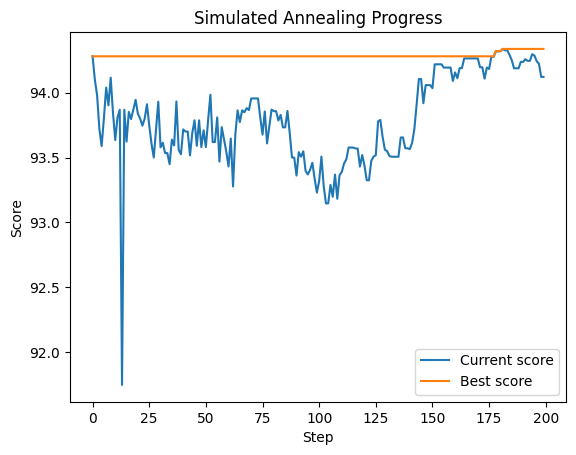

In [ ]:
#Simulated Annealing, kiértékelés csak a minisim-en keresztül
RUN_SIM = True
MINISIM_GAMES_PER_SIM = 100
REPS = 200
MUTATE_TYPE = 'normal'

def compute_cooling_rate(reps, T0=1.0, Tend=0.01):
    return (Tend / T0) ** (1 / reps)

def deck_key(deck):
    return tuple(sorted(deck.items()))

def cached_evaluate(deck, num_sim):
    #Ne kelljen ugyanazt a paklit többször kiértékelni
    key = deck_key(deck)
    if key in score_cache:
        return score_cache[key]
    score = evaluate_minisim(deck, num_sim)
    score_cache[key] = score
    return score


if RUN_SIM:
    #Megnyitjuk a log-ot, ahová az eredményeket fogjuk menteni
    with open(LOG_PATH, "w", encoding="utf-8") as f:
        f.write("SIMULATED ANNEALING LOG\n\n")

    current_deck = read_deck("Custom_deck")
    current_score = evaluate_minisim(current_deck, MINISIM_GAMES_PER_SIM)
    print("STARTING DECK SCORE:", current_score)
    print("STARTING DECK:")
    print(current_deck)
    best_deck = current_deck.copy()
    best_score = current_score
    cooling_rate = compute_cooling_rate(REPS)
    T = 5
    score_cache = {}

    #Plotoláshoz
    history = {
        "step": [],
        "current": [],
        "best": [],
        "candidate": []
    }

    print("Starting process...")

    for step in range(REPS):
        match MUTATE_TYPE:
            case 'random':
                candidate, added, removed = random_change(current_deck)
            case 'hard':
                candidate, added, removed = hard_mutate(current_deck)
            case 'normal':
                candidate, added, removed = mutate(current_deck)
            case _:
                candidate, added, removed = mutate(current_deck)
        accepted = False
        prob = 1.0
        current_sims = int(50 + (MINISIM_GAMES_PER_SIM-50) * (step / REPS))
        candidate_score = cached_evaluate(candidate, current_sims)
        delta = candidate_score - current_score
        #Eldöntjük, hogy elfogadjuk-e a változtatást
        if delta > 0:
            accepted = True
            current_deck = candidate
            current_score = candidate_score
            if current_score > best_score:
                best_score = current_score
                best_deck = current_deck.copy()
        else:
            prob = math.exp(delta / T)
            if rd.random() < prob:
                accepted = True
                current_deck = candidate
                current_score = candidate_score
                if current_score > best_score:
                    best_score = current_score
                    best_deck = current_deck.copy()
                    write_deck(best_deck, "BEST_SO_FAR")
        #Hűlés
        T = T * cooling_rate
        #Részeredmények mentése a plotoláshoz
        history["step"].append(step)
        history["current"].append(current_score)
        history["best"].append(best_score)
        history["candidate"].append(candidate_score)
        #Részeredmény és változtatás logolása
        with open(LOG_PATH, "a", encoding="utf-8") as f:
            f.write(
                f"Step={step} | "
                f"Candidate={candidate_score:.3f} | "
                f"Current={current_score:.3f} | "
                f"Best={best_score:.3f} | "
                f"Delta={delta:.3f} | "
                f"Prob={prob:.4f} | "
                f"T={T:.4f} | "
                f"Swap=[{removed}] -> [{added}] | "
                f"Accepted={accepted}\n"
            )


    #A legjobb decket is elmentjük a log-ba
    with open(BEST_PATH, "w", encoding="utf-8") as f:
        f.write(f"BEST SCORE: {best_score:.4f}\n\n")
        for card, count in best_deck.items():
            f.write(f"{count} {card}\n")
    write_deck(best_deck, "x_BEST_FOUND")

    print("BEST SCORE:", best_score)
    print("BEST DECK:")
    print(best_deck)

    plt.figure()
    plt.plot(history["step"], history["current"], label="Current score")
    plt.plot(history["step"], history["best"], label="Best score")
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("Simulated Annealing Progress")
    plt.legend()
    plt.show()

else:
    print("RUN_SIM = False")

Forge használata az igazi keresésben:
- Amikor egy új best_deck-et találunk, megnézzük Forge-dzsal, hogy kellően kompetens-e igazi játékban
- Ha túl gyenge az így elért eredménye, akkor elutasítjuk a mutációt
- Megj.: ez a cella jó sokáig futhat, nekem 15*10 Forge-szimulációs felső határral kb. 1 óra volt

STARTING DECK SCORE: 92.21
STARTING DECK:
{'Ghost Quarter': 1, 'Mountain': 22, "Chandra's Phoenix": 4, 'Goblin Arsonist': 1, 'Grim Lavamancer': 3, 'Hero of Oxid Ridge': 1, 'Reckless Waif': 1, 'Spikeshot Elder': 3, 'Stormblood Berserker': 4, 'Stromkirk Noble': 4, 'Arc Trail': 3, 'Brimstone Volley': 1, 'Gut Shot': 2, 'Incinerate': 3, 'Volt Charge': 1, 'Koth of the Hammer': 2, 'Shrine of Burning Rage': 4}
Starting process...
Player score this simulation: 6 / 10
Player score this simulation: 5 / 10
Player score this simulation: 7 / 10
Player score this simulation: 6 / 10
Player score this simulation: 4 / 10
Player score this simulation: 5 / 10
Player score this simulation: 4 / 10
Player score this simulation: 4 / 10
Player score this simulation: 3 / 10
Player score this simulation: 4 / 10
Player score this simulation: 4 / 10
Player score this simulation: 2 / 10
Player score this simulation: 2 / 10
Player score this simulation: 1 / 10
Player score this simulation: 4 / 10
BEST SCORE: 93.9784

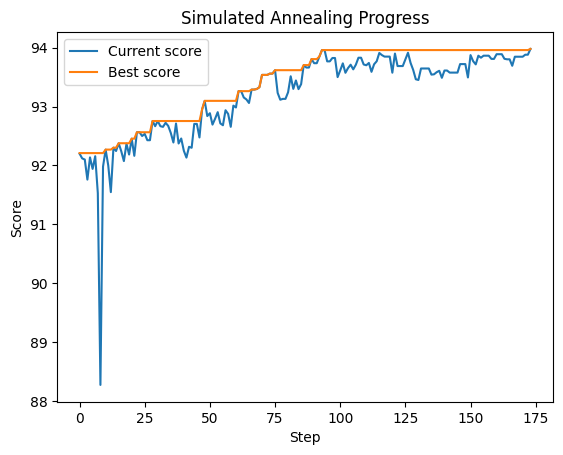

In [ ]:
#Simulated Annealing, kétlépcsős kiértékeléssel
RUN_SIM = True
REPS = 200
MINISIM_GAMES_PER_SIM = 200
MAX_FORGE_SIMS = 15
FORGE_GAMES_PER_SIM = 10
ACCEPTANCE_LIMIT = 0.3
MUTATE_TYPE = 'normal'

def compute_cooling_rate(reps, T0=1.0, Tend=0.01):
    return (Tend / T0) ** (1 / reps)

def deck_key(deck):
    return tuple(sorted(deck.items()))

minisim_cache = {}
forge_cache = {}

def cached_evaluate(deck, num_sim):
    #Ne kelljen ugyanazt a paklit többször kiértékelni
    key = deck_key(deck)
    if key in minisim_cache:
        return minisim_cache[key]
    score = evaluate_minisim(deck, num_sim)
    minisim_cache[key] = score
    return score

def cached_forge(deck):
    key = deck_key(deck)
    if key in forge_cache:
        return forge_cache[key]
    score = evaluate_forge(deck)
    forge_cache[key] = score
    return score

def evaluate_forge(current_deck):
    write_deck(current_deck)
    # FIX: mindig fix számú meccs
    winrate = simulate_games(FORGE_GAMES_PER_SIM)
    return winrate


if RUN_SIM:
    #Megnyitjuk a log-ot, ahová az eredményeket fogjuk menteni
    with open(LOG_PATH, "w", encoding="utf-8") as f:
        f.write("SIMULATED ANNEALING LOG\n\n")

    current_deck = read_deck("Custom_deck")
    current_score = cached_evaluate(current_deck, MINISIM_GAMES_PER_SIM)
    print("STARTING DECK SCORE:", current_score)
    print("STARTING DECK:")
    print(current_deck)
    best_deck = current_deck.copy()
    best_score = current_score
    cooling_rate = compute_cooling_rate(REPS)
    T = 5

    forge_sims = 0

    #Plotoláshoz
    history = {
        "step": [],
        "current": [],
        "best": [],
        "candidate": []
    }

    setup_forge()

    print("Starting process...")

    for step in range(REPS):
        match MUTATE_TYPE:
            case 'random':
                candidate, added, removed = random_change(current_deck)
            case 'hard':
                candidate, added, removed = hard_mutate(current_deck)
            case 'normal':
                candidate, added, removed = mutate(current_deck)
            case _:
                candidate, added, removed = mutate(current_deck)
        accepted = False
        prob = 1.0
        current_sims = int(50 + (MINISIM_GAMES_PER_SIM-50) * (step / REPS))
        candidate_score = cached_evaluate(candidate, current_sims)
        delta = candidate_score - current_score

        # Eldöntjük, hogy elfogadjuk-e a változtatást
        if delta > 0 or rd.random() < math.exp(delta / T):
            forge_pass = True
            #Csak akkor Forge-check, ha új best lehet
            if candidate_score > best_score:
                if step >= 50 and forge_sims < MAX_FORGE_SIMS:
                    forge_sims += 1
                    forge_score = evaluate_forge(candidate)
                    if forge_score < ACCEPTANCE_LIMIT:
                        forge_pass = False
            if forge_pass:
                accepted = True
                current_deck = candidate
                current_score = candidate_score
                if candidate_score > best_score:
                    best_score = candidate_score
                    best_deck = candidate.copy()
        else:
            accepted = False
            
        #Hűlés
        T = T * cooling_rate
        #Részeredmények mentése a plotoláshoz
        history["step"].append(step)
        history["current"].append(current_score)
        history["best"].append(best_score)
        history["candidate"].append(candidate_score)
        #Részeredmény és változtatás logolása
        with open(LOG_PATH, "a", encoding="utf-8") as f:
            f.write(
                f"Step={step} | "
                f"Candidate={candidate_score:.3f} | "
                f"Current={current_score:.3f} | "
                f"Best={best_score:.3f} | "
                f"Delta={delta:.3f} | "
                f"Prob={prob:.4f} | "
                f"T={T:.4f} | "
                f"Swap=[{removed}] -> [{added}] | "
                f"Accepted={accepted}\n"
            )
        #Második leállási feltétel: szimulációs keret kiürülése
        if forge_sims >= MAX_FORGE_SIMS:
            break

    close_forge()

    #A legjobb decket is elmentjük a log-ba
    with open(BEST_PATH, "w", encoding="utf-8") as f:
        f.write(f"BEST SCORE: {best_score:.4f}\n\n")
        for card, count in best_deck.items():
            f.write(f"{count} {card}\n")
    write_deck(best_deck, "y_BEST_FOUND")

    print("BEST SCORE:", best_score)
    print("BEST DECK:")
    print(best_deck)

    plt.figure()
    plt.plot(history["step"], history["current"], label="Current score")
    plt.plot(history["step"], history["best"], label="Best score")
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("Simulated Annealing Progress")
    plt.legend()
    plt.show()

else:
    print("RUN_SIM = False")

#Példa futtatás outputja:

STARTING DECK SCORE: 92.21 \
STARTING DECK: \
{'Ghost Quarter': 1, 'Mountain': 22, "Chandra's Phoenix": 4, 'Goblin Arsonist': 1, 'Grim Lavamancer': 3, 'Hero of Oxid Ridge': 1, 'Reckless Waif': 1, 'Spikeshot Elder': 3, 'Stormblood Berserker': 4, 'Stromkirk Noble': 4, 'Arc Trail': 3, 'Brimstone Volley': 1, 'Gut Shot': 2, 'Incinerate': 3, 'Volt Charge': 1, 'Koth of the Hammer': 2, 'Shrine of Burning Rage': 4} \
Starting process... \
Player score this simulation: 6 / 10 \
Player score this simulation: 5 / 10 \
Player score this simulation: 7 / 10 \
Player score this simulation: 6 / 10 \
Player score this simulation: 4 / 10 \
Player score this simulation: 5 / 10 \
Player score this simulation: 4 / 10 \
Player score this simulation: 4 / 10 \
Player score this simulation: 3 / 10 \
Player score this simulation: 4 / 10 \
Player score this simulation: 4 / 10 \
Player score this simulation: 2 / 10 \
Player score this simulation: 2 / 10 \
Player score this simulation: 1 / 10 \
Player score this simulation: 4 / 10 \
BEST SCORE: 93.97849462365592 \
BEST DECK: \
{'Ghost Quarter': 1, 'Mountain': 22, "Chandra's Phoenix": 1, 'Arid Mesa': 3, 'Blood Crypt': 3, 'Blackcleave Cliffs': 1, 'Burning-Tree Emissary': 2, 'Grim Lavamancer': 3, 'Stomping Ground': 2, 'Taiga': 1, 'Hellrider': 2, 'Pyrostatic Pillar': 2, 'Rootbound Crag': 1, 'Mutavault': 1, 'Wooded Foothills': 1, 'Flinthoof Boar': 2, 'Ember Hauler': 1, 'Vulshok Refugee': 1, 'Goblin Chieftain': 2, 'Hellspark Elemental': 2, 'Manic Vandal': 1, 'Stromkirk Noble': 1, 'Keldon Marauders': 1, 'Zealous Conscripts': 2, 'Flames of the Blood Hand': 1}